In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('loan_ml_ready_dataset.csv')
print("Loaded!")
print(df.shape)
print(df['loan_status'].value_counts())

Loaded!
(1345310, 201)
loan_status
0    1076751
1     268559
Name: count, dtype: int64


C:\Users\praty\AppData\Local\Temp\ipykernel_11080\834959361.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, palette=['#2ecc71', '#e74c3c'])


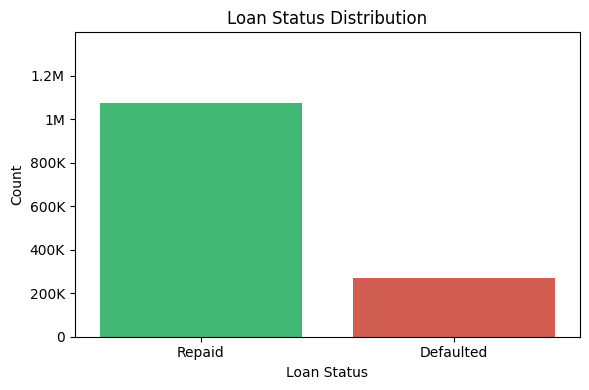

In [2]:
plt.figure(figsize=(6, 4))
sns.countplot(x='loan_status', data=df, palette=['#2ecc71', '#e74c3c'])
plt.xticks([0, 1], ['Repaid', 'Defaulted'])
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.ylim(0, 1400000)
plt.yticks([0, 200000, 400000, 600000, 800000, 1000000, 1200000],
           ['0', '200K', '400K', '600K', '800K', '1M', '1.2M'])
plt.tight_layout()
plt.show()

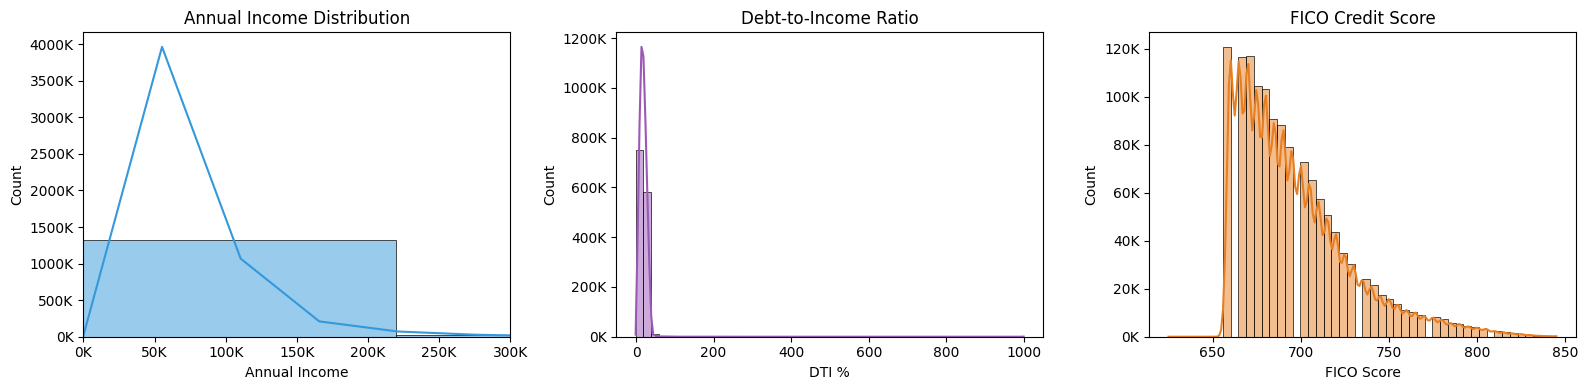

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df['annual_inc'], bins=50, ax=axes[0], color='#3498db', kde=True)
axes[0].set_title('Annual Income Distribution')
axes[0].set_xlabel('Annual Income')
axes[0].set_xlim(0, 300000)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

sns.histplot(df['dti'], bins=50, ax=axes[1], color='#9b59b6', kde=True)
axes[1].set_title('Debt-to-Income Ratio')
axes[1].set_xlabel('DTI %')

sns.histplot(df['fico_range_low'], bins=50, ax=axes[2], color='#e67e22', kde=True)
axes[2].set_title('FICO Credit Score')
axes[2].set_xlabel('FICO Score')

for ax in axes:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))

plt.tight_layout()
plt.show()

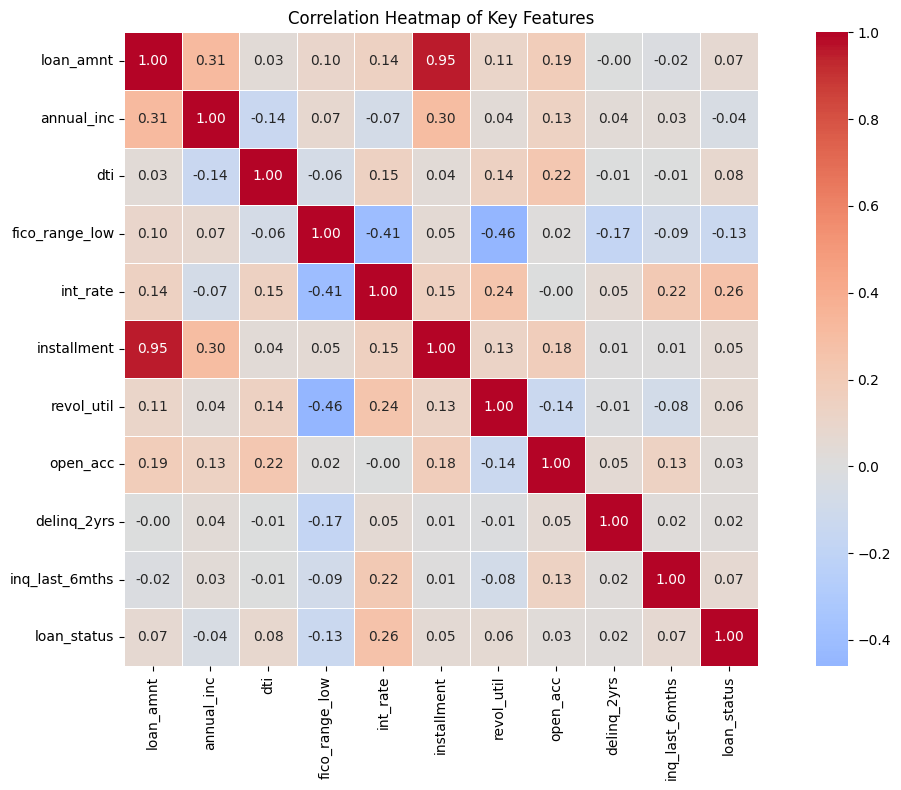

In [4]:
plt.figure(figsize=(12, 8))

key_features = ['loan_amnt', 'annual_inc', 'dti', 'fico_range_low', 
                'int_rate', 'installment', 'revol_util', 'open_acc', 
                'delinq_2yrs', 'inq_last_6mths', 'loan_status']

corr = df[key_features].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)

plt.title('Correlation Heatmap of Key Features')
plt.tight_layout()
plt.show()

In [5]:
print(df.columns.tolist())

['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'loan_status', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'n

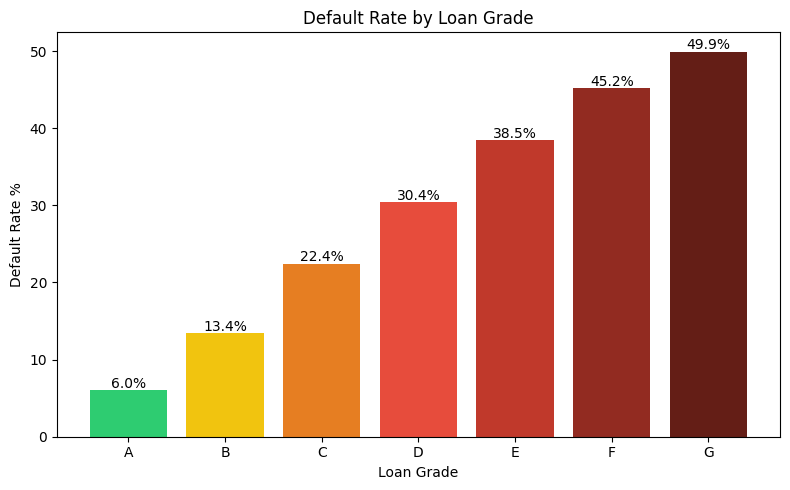

In [ ]:
grade_cols = ['grade_B', 'grade_C', 'grade_D', 'grade_E', 'grade_F', 'grade_G']
df['grade'] = 'A'
for col in grade_cols:
    df.loc[df[col] == 1, 'grade'] = col.replace('grade_', '')

grade_default = df.groupby('grade')['loan_status'].mean() * 100
grade_default = grade_default.sort_index()


plt.figure(figsize=(8, 5))
bars = plt.bar(grade_default.index, grade_default.values, 
               color=['#2ecc71','#f1c40f','#e67e22','#e74c3c','#c0392b','#922b21','#641e16'])
plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate %')
for bar, val in zip(bars, grade_default.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
             f'{val:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()